In [1]:
import warnings
warnings.filterwarnings("ignore")

import gc
import joblib
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn — model selection
from sklearn.model_selection import train_test_split, StratifiedKFold

# Sklearn — pipeline e preprocessamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Sklearn — modelos
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection    import permutation_importance

# Modelos externos
import lightgbm as lgb
from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier

# Encoders
from category_encoders import TargetEncoder
import json


pd.set_option('display.float_format', '{:.4f}'.format)

hoje = date.today()

### Importando Book -> Tirando Mau na Origem e Target missing

In [2]:
df_treino = pd.read_csv(r'C:\Users\muril\OneDrive\Desktop\Fonte\application_train.csv', sep=',', encoding='utf-8')
df_treino = df_treino[~df_treino['TARGET'].isna()]

df_teste = pd.read_csv(r'C:\Users\muril\OneDrive\Desktop\Fonte\application_test.csv', sep=',', encoding='utf-8')

Importância de Variáveis

In [3]:
X = df_treino.drop(columns=['SK_ID_CURR','TARGET'])
y = df_treino['TARGET']

In [4]:
# 1- Remover variáveis com baixa variância

def remove_low_variance(X, threshold=0.01):
    X_num = X.select_dtypes(exclude='object')
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_num.fillna(X_num.median()))  # VarianceThreshold não aceita NaN
    cols_selected = X_num.columns[selector.get_support()]
    return cols_selected


# 2- IV e KS univariados (específico do application — substitui o papel do PSI
# do behavioral, já que aqui não existe safra pra checar estabilidade temporal)

def calcular_iv_ks(X, y, coluna, n_bins=10):
    '''Calcula IV (via WOE por bins) e KS univariado de uma variável numérica.'''
    dados = pd.DataFrame({'var': X[coluna], 'target': y}).dropna()
    if dados.empty or dados['target'].nunique() < 2:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': X[coluna].isnull().mean()}

    try:
        dados['bin'] = pd.qcut(dados['var'], q=n_bins, duplicates='drop')
    except ValueError:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': X[coluna].isnull().mean()}

    grp = dados.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    grp['bom'] = grp['count'] - grp['sum']
    grp['mau'] = grp['sum']
    total_bom = grp['bom'].sum()
    total_mau = grp['mau'].sum()

    grp['pct_bom'] = grp['bom'] / total_bom
    grp['pct_mau'] = grp['mau'] / total_mau
    grp['woe'] = np.log((grp['pct_bom'].replace(0, 1e-6)) / (grp['pct_mau'].replace(0, 1e-6)))
    grp['iv_bin'] = (grp['pct_bom'] - grp['pct_mau']) * grp['woe']
    iv = grp['iv_bin'].sum()

    grp_sorted = grp.sort_index()
    ks = (grp_sorted['pct_bom'].cumsum() - grp_sorted['pct_mau'].cumsum()).abs().max()

    return {
        'variavel': coluna,
        'iv': round(iv, 4),
        'ks': round(ks, 4),
        'pct_missing': round(X[coluna].isnull().mean() * 100, 2)
    }


def iv_ks_filter(X, y, cols, iv_min=0.02, n_bins=10):
    '''Roda IV/KS para uma lista de colunas numéricas e filtra pelo IV mínimo.'''
    resultados = [calcular_iv_ks(X, y, c, n_bins=n_bins) for c in cols]
    df_iv = pd.DataFrame(resultados).sort_values('iv', ascending=False).reset_index(drop=True)
    cols_aprovadas = df_iv.loc[df_iv['iv'] >= iv_min, 'variavel'].tolist()
    return df_iv, cols_aprovadas


# 3- Correlação entre variáveis numéricas

def correlation_filter(X, threshold=0.90):
    X_num       = X.select_dtypes(include=np.number)
    corr_matrix = X_num.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    remove      = [column for column in upper.columns if any(upper[column] > threshold)]
    return remove


# 4- Feature importance LightGBM

def lgbm_feature_importance(X_train, y_train, cat_cols=None):
    X_fit = X_train.copy()
    if cat_cols:
        for c in cat_cols:
            X_fit[c] = X_fit[c].astype('category')

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbose=-1
    )
    model.fit(X_fit, y_train, categorical_feature=cat_cols if cat_cols else 'auto')
    importance = pd.DataFrame({
        "variavel"  : X_fit.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance


# 5- Rodar seleção
# Diferença chave vs behavioral: não filtramos safra (não existe),
# e o split é só um holdout estratificado simples, sem OOT.

COLS_TIRAR_SEL = ['SK_ID_CURR', 'TARGET']
cols_remover_sel = [c for c in COLS_TIRAR_SEL if c in df_treino.columns]

X_sel = df_treino.drop(columns=cols_remover_sel).copy()
y_sel = df_treino['TARGET']

X_sel_train, X_sel_test, y_sel_train, _ = train_test_split(
    X_sel, y_sel, test_size=0.30, stratify=y_sel, random_state=42
)

print("Shape inicial:", X_sel_train.shape)

cat_cols_sel = X_sel_train.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas identificadas:", len(cat_cols_sel))

cols_lowvar = remove_low_variance(X_sel_train, threshold=0.01)
print("\nApós baixa variância:", len(cols_lowvar))

df_iv, cols_iv_aprovadas = iv_ks_filter(X_sel_train, y_sel_train, cols_lowvar, iv_min=0.02)
print("Após filtro de IV (>= 0.02):", len(cols_iv_aprovadas))
print(df_iv.head(15))

corr_remove = correlation_filter(X_sel_train[cols_iv_aprovadas], threshold=0.90)
print("\nVariáveis removidas por correlação:", len(corr_remove))

cols_finais_num = [c for c in cols_iv_aprovadas if c not in corr_remove]
cols_finais = cols_finais_num + cat_cols_sel

X_final_train = X_sel_train[cols_finais]
print("Shape final após filtros:", X_final_train.shape)

importance = lgbm_feature_importance(X_final_train, y_sel_train, cat_cols=cat_cols_sel)
importance

Shape inicial: (215257, 120)
Colunas categóricas identificadas: 16

Após baixa variância: 45
Após filtro de IV (>= 0.02): 18
                       variavel     iv     ks  pct_missing
0                  EXT_SOURCE_3 0.4070 0.2675      19.8300
1                  EXT_SOURCE_1 0.3513 0.2431      56.3900
2                  EXT_SOURCE_2 0.3085 0.2215       0.2200
3                 DAYS_EMPLOYED 0.1026 0.0830       0.0000
4               AMT_GOODS_PRICE 0.0921 0.0965       0.0900
5                    DAYS_BIRTH 0.0862 0.1213       0.0000
6                   OWN_CAR_AGE 0.0523 0.1002      66.0100
7                    AMT_CREDIT 0.0451 0.0660       0.0000
8        DAYS_LAST_PHONE_CHANGE 0.0447 0.0928       0.0000
9               DAYS_ID_PUBLISH 0.0373 0.0836       0.0000
10               FLOORSMAX_MEDI 0.0323 0.0683      49.6900
11                FLOORSMAX_AVG 0.0322 0.0685      49.6900
12               FLOORSMAX_MODE 0.0309 0.0645      49.6900
13  REGION_RATING_CLIENT_W_CITY 0.0283 0.0627    

,variavel,importance
0,ORGANIZATION_TYPE,388
1,EXT_SOURCE_1,214
2,EXT_SOURCE_3,208
3,AMT_GOODS_PRICE,181
4,EXT_SOURCE_2,179
5,DAYS_BIRTH,126
6,AMT_ANNUITY,111
7,DAYS_EMPLOYED,88
8,DAYS_ID_PUBLISH,79
9,OCCUPATION_TYPE,78


Salvando Lista das Top Variáveis

In [5]:
importance = importance[importance['importance'] > 0]
vars = importance['variavel'].to_list()
vars = vars[:31]

## Parte 1 — Preparando os dados (sem treinar ainda)

In [6]:
# ATENÇÃO: aqui só preparamos os dados (split + imputação + encoding).

COLS_TIRAR_TREINO = ['SK_ID_CURR', 'TARGET']
cols_remover_treino = [c for c in COLS_TIRAR_TREINO if c in df_treino.columns]

X = df_treino.drop(columns=cols_remover_treino)
y = df_treino['TARGET']

X = X[vars]

# Base oficial de teste da Home Credit — guarda o SK_ID_CURR à parte,
# ele não entra no modelo mas é obrigatório na submissão final.
ids_teste = df_teste['SK_ID_CURR'].copy()
X_teste = df_teste[vars].copy()  # mesmas colunas selecionadas

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Guarda os SK_ID_CURR do holdout e do treino, alinhados por índice — vai
ids_train = df_treino.loc[X_train.index, 'SK_ID_CURR'].values
ids_test  = df_treino.loc[X_test.index,  'SK_ID_CURR'].values

# ======================================================
# Identificação das colunas
# ======================================================

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# ======================================================
# Missing numéricos (média calculada no treino)
# Aplicado nas 3 bases: X_train (fit), X_test (transform), X_teste (transform)
# ======================================================

means = X_train[num_cols].mean()

X_train[num_cols] = X_train[num_cols].fillna(means)
X_test[num_cols]  = X_test[num_cols].fillna(means)
X_teste[num_cols] = X_teste[num_cols].fillna(means)

# ======================================================
# Missing categóricos
# ======================================================

X_train[cat_cols] = X_train[cat_cols].fillna("MISSING")
X_test[cat_cols]  = X_test[cat_cols].fillna("MISSING")
X_teste[cat_cols] = X_teste[cat_cols].fillna("MISSING")

encoder = TargetEncoder(cols=cat_cols)

X_train = encoder.fit_transform(X_train, y_train)
X_test  = encoder.transform(X_test)
X_teste = encoder.transform(X_teste)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| X_teste (Kaggle):", X_teste.shape)

X_train: (215257, 28) | X_test: (92254, 28) | X_teste (Kaggle): (48744, 28)


## Comparação de modelos

In [7]:
# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos
# (idêntico ao behavioral — a comparação de algoritmos não muda entre
# application e behavior, o que muda é a leitura das métricas)
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
# ======================================================

resultados = []

for nome, modelo in models.items():

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    prob_train = modelo.predict_proba(X_train)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_test)
    prob_test = modelo.predict_proba(X_test)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,LightGBM,0.9204,0.9198,0.7193,0.6047,0.0236,0.0175,0.7957,0.7563,0.5914,0.5127,0.4394,0.3826,0.0394,0.0568,0.0007
1,CatBoost,0.9201,0.9198,0.6897,0.6301,0.0178,0.0146,0.7617,0.7560,0.5235,0.5119,0.3896,0.3849,0.0058,0.0047,0.0003
2,GradientBoosting,0.9216,0.9197,0.7809,0.5597,0.0396,0.0239,0.7882,0.7559,0.5764,0.5118,0.4297,0.3834,0.0323,0.0463,0.0019
3,Random Forest,0.9193,0.9193,0.0000,0.0000,0.0000,0.0000,0.7371,0.7351,0.4742,0.4702,0.3525,0.3440,0.0020,0.0085,0.0000
4,LogisticRegression,0.9192,0.9193,0.2941,0.6250,0.0006,0.0013,0.7178,0.7200,0.4356,0.4399,0.3201,0.3236,-0.0022,-0.0034,-0.0001


In [10]:
nome_campeao = "CatBoost"
modelo_campeao = models[nome_campeao]
print(f"Modelo campeão pelo ROC AUC Test: {nome_campeao}")

# Probabilidades -> vão ser reaproveitadas na Parte 2 (faixas de risco)
y_prob_train = modelo_campeao.predict_proba(X_train)[:, 1]
y_prob_test  = modelo_campeao.predict_proba(X_test)[:, 1]
y_prob_kaggle = modelo_campeao.predict_proba(X_teste)[:, 1]

submissao = pd.DataFrame({
    'SK_ID_CURR': ids_teste,
    'TARGET': y_prob_kaggle
})

submissao.to_csv('submissao_home_credit.csv', index=False)
submissao.head()

Modelo campeão pelo ROC AUC Test: CatBoost


,SK_ID_CURR,TARGET
0,100001,0.0582
1,100005,0.1397
2,100013,0.0252
3,100028,0.0380
4,100038,0.1328


## Parte 2 - Criando Faixas de risco com o qcut

In [ ]:
N_FAIXAS = 100

score_train = (y_prob_train * 1000).astype(int)

_, bins = pd.qcut(score_train, q=N_FAIXAS, duplicates='drop', retbins=True)
bins[0]  = -np.inf 
bins[-1] = np.inf    

n_faixas_reais = len(bins) - 1
labels_faixa = [f"{i+1}) Faixa {i+1}" for i in range(n_faixas_reais)]
print(f"Faixas geradas: {n_faixas_reais} (de {N_FAIXAS} solicitadas)")

df_score_train = pd.DataFrame({
    'SK_ID_CURR'   : ids_train,
    'target'       : y_train.values,
    'probabilidade': y_prob_train.round(4),
    'score'        : score_train
})
df_score_train['faixa_score'] = pd.cut(
    df_score_train['score'], bins=bins, labels=labels_faixa, include_lowest=True
)


analise_faixas_treino = (
    df_score_train
    .groupby('faixa_score', observed=True)
    .agg(
        qtd_clientes = ('score',  'count'),
        qtd_maus     = ('target', 'sum'),
        score_max    = ('score',  'max'),
    )
    .assign(
        taxa_inadimp   = lambda d: (d['qtd_maus'] / d['qtd_clientes'] * 100).round(2),
        taxa_acumulada = lambda d: (d['qtd_maus'].cumsum() / d['qtd_maus'].sum() * 100).round(2)
    )
    .reset_index()
)
print(analise_faixas_treino)

file_path_analiseFaixas = r'C:\Users\muril\OneDrive\Home_Credit_Default_Risk\02-ScorandoBase_Padrao\Criando_FaixasRisco\01Criacao_FaixaScore_BaseTreino.xlsx'
analise_faixas_treino.to_excel(file_path_analiseFaixas, index=False)

Faixas geradas: 94 (de 100 solicitadas)
Score treino — min: 2 | max: 746 | média: 80
     faixa_risco  qtd_clientes  qtd_maus  score_max  taxa_inadimp  \
0     1) Faixa 1          2354        13          9        0.5500   
1     2) Faixa 2          2446        25         11        1.0200   
2     3) Faixa 3          3335        32         13        0.9600   
3     4) Faixa 4          2003        22         14        1.1000   
4     5) Faixa 5          2221        39         15        1.7600   
..           ...           ...       ...        ...           ...   
89  90) Faixa 90          2064       549        253       26.6000   
90  91) Faixa 91          2145       608        277       28.3400   
91  92) Faixa 92          2172       655        313       30.1600   
92  93) Faixa 93          2147       783        371       36.4700   
93  94) Faixa 94          2138      1093        746       51.1200   

    taxa_acumulada  
0           0.0700  
1           0.2200  
2           0.4000  
3 

### Replicando faixas de risco na base de teste

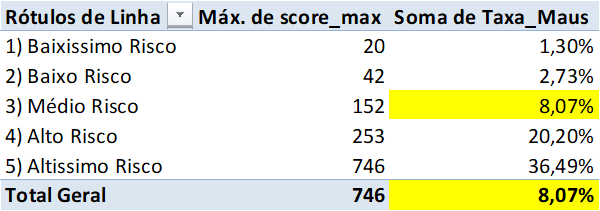

In [ ]:
score_train = (y_prob_train * 1000).astype(int)

df_score_train = pd.DataFrame({
    'SK_ID_CURR'   : ids_train,
    'target'       : y_train.values,
    'probabilidade': y_prob_train.round(4),
    'score'        : score_train
})

conditions = [
    df_score_train['score'] <= 20,
    df_score_train['score'] <= 42,
    df_score_train['score'] <= 152,
    df_score_train['score'] <= 253,
]
choices = ['1) Baixissimo Risco', '2) Baixo Risco', '3) Medio Risco', '4) Alto Risco']

df_score_train['faixa_score'] = np.select(conditions, choices, default='5) Altissimo Risco')
df_score_train['qtde'] = 1

file_path_treinoEscorado = r'C:\Users\muril\OneDrive\Home_Credit_Default_Risk\02-ScorandoBase_Padrao\Criando_FaixasRisco\02-BaseTreino_FaixasRiscoValidadas1.xlsx'
df_score_train.to_excel(file_path_treinoEscorado, index=False)

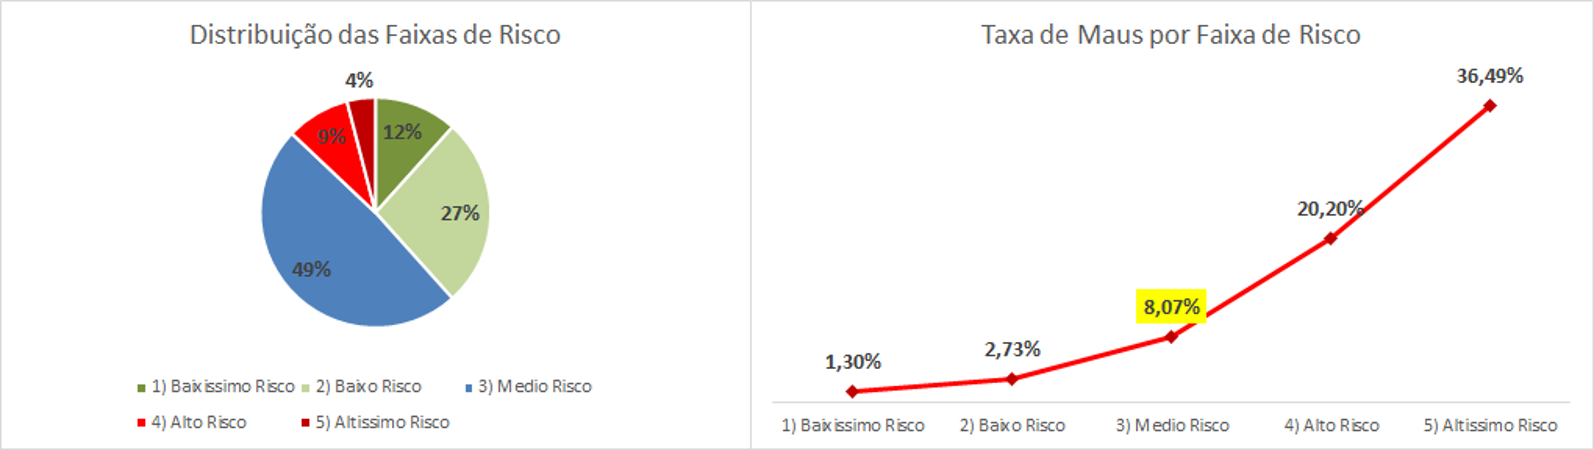

### Aplicando as mesmas faixas na base oficial de teste

In [ ]:
score_test = (y_prob_test * 1000).astype(int)

df_score_test = pd.DataFrame({
    'SK_ID_CURR'   : ids_test,
    'target'       : y_test.values,
    'probabilidade': y_prob_test.round(4),
    'score'        : score_test
})

conditions = [
    df_score_test['score'] <= 20,
    df_score_test['score'] <= 42,
    df_score_test['score'] <= 152,
    df_score_test['score'] <= 253,
]
choices = ['1) Baixissimo Risco', '2) Baixo Risco', '3) Medio Risco', '4) Alto Risco']

df_score_test['faixa_score'] = np.select(conditions, choices, default='5) Altissimo Risco')
df_score_test['qtde'] = 1

file_path_testEscorado = r'C:\Users\muril\OneDrive\Home_Credit_Default_Risk\02-ScorandoBase_Padrao\Criando_FaixasRisco\03-BaseTest_FaixasRiscoValidadas.xlsx'
df_score_test.to_excel(file_path_testEscorado, index=False)

### Concatenando as bases — Treino & Teste

In [ ]:
df_score_train['split'] = 'Treino'
df_score_test['split']  = 'Teste'

df_full = pd.concat([
    df_score_train[['SK_ID_CURR', 'score', 'faixa_score', 'split']],
    df_score_test[[ 'SK_ID_CURR', 'score', 'faixa_score', 'split']]
], ignore_index=True)

print(df_full.shape)
print(df_full['split'].value_counts())
print(df_full.head())

file_path_full = r'C:\Users\muril\OneDrive\Home_Credit_Default_Risk\02-ScorandoBase_Padrao\Criando_FaixasRisco\04-Base_ConcatTreinoTeste.xlsx'
df_full.to_excel(file_path_full, index=False)
print('Salvo.')

(307511, 4)
split
Treino    215257
Teste      92254
Name: count, dtype: int64
   SK_ID_CURR  score     faixa_score   split
0      285133     35  2) Baixo Risco  Treino
1      191894     88  3) Medio Risco  Treino
2      369428     71  3) Medio Risco  Treino
3      138717     41  2) Baixo Risco  Treino
4      202381     26  2) Baixo Risco  Treino
Salvo.
